In [ ]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.5 MB/s eta 0:00:00


In [ ]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0

In [ ]:
%cd /content/CENSOR

/content/CENSOR


In [ ]:
import numpy as np
import torch

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

NumPy: 1.26.4
Torch: 2.2.0+cu121
CUDA: True


In [ ]:
!pip install FrEIA nevergrad

In [ ]:
import yaml

with open("configs_biggan.yml", "r") as f:
    cfg = yaml.safe_load(f)

cfg["dataset"] = "CIFAR10"
cfg["data_path"] = "./data"

with open("configs_biggan.yml", "w") as f:
    yaml.dump(cfg, f)

print("Config patched!")

Config patched!


In [ ]:
import os

file_path = "/content/CENSOR/inversefed/utils.py"

with open(file_path, "r") as f:
    content = f.read()

content = content.replace(
    "data = old_table.append(kwargs, ignore_index=True)",
    "data = pd.concat([old_table, pd.DataFrame([kwargs])], ignore_index=True)"
)

content = content.replace(
    "data = data.append(kwargs, ignore_index=True)",
    "data = pd.concat([data, pd.DataFrame([kwargs])], ignore_index=True)"
)

with open(file_path, "w") as f:
    f.write(content)

print("Patched pandas append issue!")

Patched pandas append issue!


In [ ]:
import yaml

with open("configs_biggan.yml", "r") as f:
    cfg = yaml.safe_load(f)

cfg["batch_size"] = 1

with open("configs_biggan.yml", "w") as f:
    yaml.dump(cfg, f)

print("Batch size reduced")

FileNotFoundError: [Errno 2] No such file or directory: 'configs_biggan.yml'

In [ ]:
!python run_rec.py --config configs_biggan.yml

--------------------------------------------------------------------------------
Process ID: 14560
output_dir: /scratch/gilbreth/zhan4057/gradinv/results_biggan/ex1_biggan_imagenet_num_images_1_defense_representation_May.07_07.04.05
Currently evaluating -------------------------------:
Thursday, 07. May 2026 07:04AM
CPUs: 1, GPUs: 1 on ad422dd77b92.
GPU : Tesla T4
Config for this experiment is saved
Files already downloaded and verified
Files already downloaded and verified
Set seed:123
Model initialized with random key 123.
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    lr: 0.1
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0005
)
Epoch 0 started,saved at /scratch/gilbreth/zhan4057/gradinv/results_biggan/ex1_biggan_imagenet_num_images_1_defense_representation_May.07_07.04.05/epoch_0
Creating a new .csv table...
/content/CENSOR/inversefed/utils.py:53: FutureWarning: The behavior of DataFrame concatenati

Device: cuda
Real gradients computed
Defense Applied

Starting reconstruction...

Iteration 0 | Gradient Loss: 611.3412
Iteration 50 | Gradient Loss: 1.8402
Iteration 100 | Gradient Loss: 1.3245
Iteration 150 | Gradient Loss: 1.3204
Iteration 200 | Gradient Loss: 1.3214
Iteration 250 | Gradient Loss: 1.3214
Iteration 300 | Gradient Loss: 1.3211
Iteration 350 | Gradient Loss: 1.3211
Iteration 400 | Gradient Loss: 1.3212
Iteration 450 | Gradient Loss: 1.3212
Iteration 500 | Gradient Loss: 1.3211
Iteration 550 | Gradient Loss: 1.3221
Iteration 600 | Gradient Loss: 1.3212
Iteration 650 | Gradient Loss: 1.3211
Iteration 700 | Gradient Loss: 1.3211
Iteration 750 | Gradient Loss: 1.3203
Iteration 800 | Gradient Loss: 1.3205
Iteration 850 | Gradient Loss: 1.3207
Iteration 900 | Gradient Loss: 1.3215
Iteration 950 | Gradient Loss: 1.3215
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth

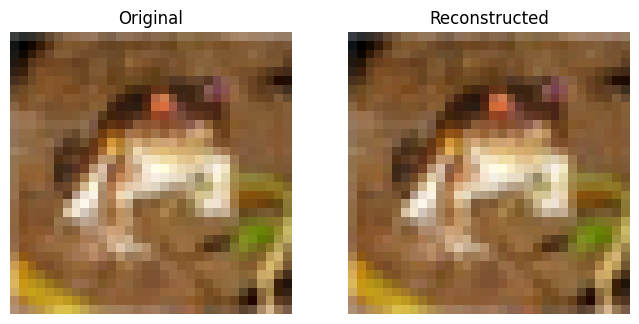


RECONSTRUCTION METRICS
PSNR  : 46.7790
SSIM  : 0.9989
LPIPS : 0.0000

DONE!


In [ ]:
# ============================================================
# SIMPLE GRADIENT INVERSION + PSNR + SSIM + LPIPS
# ONE CELL VERSION
# ============================================================

# Install LPIPS
!pip install lpips -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

import lpips

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ============================================================
# LOAD CIFAR10
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

img, label = dataset[0]

img = img.unsqueeze(0).to(device)
label = torch.tensor([label]).to(device)

# ============================================================
# SIMPLE CNN
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),

            nn.Flatten(),

            nn.Linear(32*32*32, 10)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleCNN().to(device)

# ============================================================
# COMPUTE REAL GRADIENTS
# ============================================================

criterion = nn.CrossEntropyLoss()

pred = model(img)
loss = criterion(pred, label)

real_grads = torch.autograd.grad(
    loss,
    model.parameters()
)

real_grads = [g.detach().clone() for g in real_grads]

print("Real gradients computed")

# ============================================================
# DEFENSE SWITCH
# ============================================================

USE_DEFENSE = True

if USE_DEFENSE:

    defended_grads = []

    for g in real_grads:

        noise = torch.randn_like(g) * 0.002
        defended_grads.append(g + noise)

    target_grads = defended_grads

    print("Defense Applied")

else:

    target_grads = real_grads

    print("No Defense")

# ============================================================
# INITIALIZE DUMMY IMAGE
# ============================================================

dummy_img = torch.randn_like(
    img,
    requires_grad=True,
    device=device
)

optimizer = optim.Adam([dummy_img], lr=0.1)

# ============================================================
# ATTACK LOOP
# ============================================================

iterations = 1000

print("\nStarting reconstruction...\n")

for i in range(iterations):

    optimizer.zero_grad()

    dummy_pred = model(dummy_img)

    dummy_loss = criterion(dummy_pred, label)

    dummy_grads = torch.autograd.grad(
        dummy_loss,
        model.parameters(),
        create_graph=True
    )

    grad_loss = 0

    for dg, rg in zip(dummy_grads, target_grads):

        grad_loss += ((dg - rg) ** 2).sum()

    grad_loss.backward()

    optimizer.step()

    dummy_img.data.clamp_(0,1)

    if i % 50 == 0:

        print(
            f"Iteration {i} | "
            f"Gradient Loss: {grad_loss.item():.4f}"
        )

# ============================================================
# PREPARE IMAGES
# ============================================================

original = img.detach().cpu()[0]
reconstructed = dummy_img.detach().cpu()[0]

original_np = original.permute(1,2,0).numpy()
reconstructed_np = reconstructed.permute(1,2,0).numpy()

# ============================================================
# PSNR
# ============================================================

psnr = compare_psnr(
    original_np,
    reconstructed_np,
    data_range=1.0
)

# ============================================================
# SSIM
# ============================================================

ssim = compare_ssim(
    original_np,
    reconstructed_np,
    channel_axis=2,
    data_range=1.0
)

# ============================================================
# LPIPS
# ============================================================

loss_fn = lpips.LPIPS(net='alex').to(device)

lpips_score = loss_fn(
    img,
    dummy_img
).item()

# ============================================================
# DISPLAY RESULTS
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(original_np)
ax[0].set_title("Original")
ax[0].axis('off')

ax[1].imshow(reconstructed_np)
ax[1].set_title("Reconstructed")
ax[1].axis('off')

plt.show()

# ============================================================
# PRINT METRICS
# ============================================================

print("\n==============================")
print("RECONSTRUCTION METRICS")
print("==============================")

print(f"PSNR  : {psnr:.4f}")
print(f"SSIM  : {ssim:.4f}")
print(f"LPIPS : {lpips_score:.4f}")

print("\nDONE!")